# HR ATTRITION ANALYTICS

Companies typically only find out an employee is leaving when they hand
in their resignation — too late to do anything about it. This project
turns that into a data problem: can we predict attrition risk before
someone resigns, and understand why people are leaving, so HR and
managers can act early instead of reactively?

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r'C:\Users\Jumbo\OneDrive\Desktop\HR-Attrition\hr_attrition_data_raw.csv')
pd.set_option('display.max_columns', None)
df.head(10)

,EmployeeID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,JobRole,MonthlyIncome,MaritalStatus,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
0,1,41.0,No,Travel_Rarely,Research & Development,3,2,Marketing,4.0,Female,1,2.0,Research Director,6758.0,Single,1.0,No,15,3,1,17,0,4,4,1
1,2,35.0,No,Travel_Rarely,Sales,7,2,Medical,1.0,Female,4,2.0,Sales Representative,7699.0,Divorced,0.0,No,17,3,1,11,3,2,3,2
2,3,18.0,Yes,Travel_Rarely,Sales,11,3,Medical,1.0,Male,1,3.0,Sales Representative,7731.0,Single,4.0,Yes,17,4,2,0,1,1,0,0
3,4,43.0,No,Travel_Rarely,NaN,3,5,Marketing,1.0,Male,3,3.0,Research Scientist,6626.0,Married,3.0,Yes,14,3,1,19,3,3,2,2
4,5,29.0,No,Travel_Rarely,Research & Development,6,4,Technical Degree,1.0,M,1,2.0,Research Director,7046.0,Single,4.0,Yes,13,4,0,5,2,4,5,4
5,6,40.0,No,Travel_Rarely,Research & Development,29,3,Human Resources,2.0,Female,2,4.0,Research Scientist,9057.0,Divorced,3.0,Yes,14,3,1,17,3,4,1,1
6,7,37.0,No,Travel_Frequently,Sales,9,4,Technical Degree,2.0,Female,1,3.0,Sales Executive,8128.0,Single,1.0,No,11,3,2,12,3,4,5,4
7,8,38.0,No,Travel_Rarely,Sales,1,4,Technical Degree,2.0,Female,2,1.0,Manager,10937.0,Single,1.0,No,16,3,1,17,3,4,10,3
8,9,40.0,No,Travel_Rarely,Research & Development,18,3,Human Resources,1.0,Female,3,4.0,Research Scientist,7735.0,Married,3.0,No,14,3,2,14,0,4,3,2
9,10,33.0,No,Non-Travel,Research & Development,1,3,Other,2.0,Female,2,3.0,Research Director,10124.0,Divorced,3.0,Yes,14,3,0,11,2,3,11,4


In [4]:
df.shape

(1485, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               1485 non-null   int64  
 1   Age                      1474 non-null   float64
 2   Attrition                1485 non-null   object 
 3   BusinessTravel           1485 non-null   object 
 4   Department               1458 non-null   object 
 5   DistanceFromHome         1485 non-null   int64  
 6   Education                1485 non-null   int64  
 7   EducationField           1485 non-null   object 
 8   EnvironmentSatisfaction  1455 non-null   float64
 9   Gender                   1485 non-null   object 
 10  JobInvolvement           1485 non-null   int64  
 11  JobSatisfaction          1461 non-null   float64
 12  JobRole                  1485 non-null   object 
 13  MonthlyIncome            1442 non-null   float64
 14  MaritalStatus           

In [6]:
df.dtypes

EmployeeID                   int64
Age                        float64
Attrition                   object
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction    float64
Gender                      object
JobInvolvement               int64
JobSatisfaction            float64
JobRole                     object
MonthlyIncome              float64
MaritalStatus               object
NumCompaniesWorked         float64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole           int64
dtype: object

In [7]:
df.describe(include='all')

,EmployeeID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,JobRole,MonthlyIncome,MaritalStatus,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
count,1485.000000,1474.000000,1485,1485,1458,1485.000000,1485.000000,1485,1455.000000,1485,1485.000000,1461.000000,1485,1442.000000,1485,1453.000000,1485,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000
unique,NaN,NaN,2,3,13,NaN,NaN,6,NaN,8,NaN,NaN,9,NaN,3,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,No,Travel_Rarely,Research & Development,NaN,NaN,Life Sciences,NaN,Female,NaN,NaN,Manager,NaN,Married,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1282,1071,850,NaN,NaN,263,NaN,716,NaN,NaN,378,NaN,684,NaN,1062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,734.195960,36.727273,NaN,NaN,NaN,7.212121,3.004714,NaN,2.453608,NaN,2.474747,2.472964,NaN,7367.181692,NaN,2.504474,NaN,15.003367,3.154209,1.006734,14.303704,2.738721,2.553535,3.630976,1.105724
std,424.845477,11.805115,NaN,NaN,NaN,7.024513,1.072496,NaN,1.123899,NaN,1.113596,1.123894,NaN,2245.895088,NaN,1.587056,NaN,3.498073,0.361270,0.990498,8.712928,1.553759,1.125840,4.091917,1.512393
min,1.000000,-52.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000,NaN,1.000000,1.000000,NaN,-10832.000000,NaN,0.000000,NaN,11.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,367.000000,30.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,1.000000,NaN,1.000000,1.000000,NaN,6186.000000,NaN,1.000000,NaN,12.000000,3.000000,0.000000,8.000000,2.000000,2.000000,1.000000,0.000000
50%,732.000000,37.000000,NaN,NaN,NaN,5.000000,3.000000,NaN,2.000000,NaN,2.000000,2.000000,NaN,7368.500000,NaN,2.000000,NaN,14.000000,3.000000,1.000000,14.000000,3.000000,3.000000,2.000000,1.000000
75%,1102.000000,43.000000,NaN,NaN,NaN,11.000000,4.000000,NaN,3.000000,NaN,3.000000,3.000000,NaN,8640.750000,NaN,4.000000,NaN,17.000000,3.000000,2.000000,20.000000,4.000000,4.000000,5.000000,2.000000


We have the EmployeeID count as 1485 but the maximum value is 1470 Which indicates the presence of duplicates. 
The Age column has maximum value 181 which is invalid. 
In MonthlyIncome column the minimum value is negative which is invalid.
Gender column shows 8 unique values which indicates there is data inconsistency.
Department column shows 13 unique values but there is only 3 departments which indicates data inconsistency.
Overtime columnshows 8 unique values instead of 2(yes/no) which shows data inconsistency.





Data Cleaning

In [8]:
df.isna().sum()

EmployeeID                  0
Age                        11
Attrition                   0
BusinessTravel              0
Department                 27
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction    30
Gender                      0
JobInvolvement              0
JobSatisfaction            24
JobRole                     0
MonthlyIncome              43
MaritalStatus               0
NumCompaniesWorked         32
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(15)

In [10]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows")

Removed 15 exact duplicate rows


In [11]:
print(f"Unique values in 'Gender': {df['Gender'].unique()}")

print(f"Unique values in 'Department':{df['Department'].unique()}")

print(f"Unique values in 'OverTime':{df['OverTime'].unique()}")


Unique values in 'Gender': ['Female' 'Male' 'M' 'male' 'female' 'MALE' 'F' 'FEMALE']
Unique values in 'Department':['Research & Development' 'Sales' nan 'Sales ' 'R&D'
 ' Research & Development' 'Human Resources' 'research & development'
 'SALES' 'sales' 'Human Resources ' ' Sales' 'human resources' 'HR']
Unique values in 'OverTime':['No' 'Yes' 'N' 'NO' 'no' 'yes' 'YES' 'Y']


In [12]:
#standardize categorical text (case, whitespace and abbreviations)

def clean_category(series, mapping):
    s = series.copy()
    mask = s.notna()
    s.loc[mask] = s.loc[mask].astype(str).str.strip()
    s.loc[mask] = s.loc[mask].replace(mapping)
    canon = {v.lower(): v for v in set(mapping.values())}
    s.loc[mask] = s.loc[mask].apply(lambda x: canon.get(x.lower(), x))
    return s


In [13]:
dept_map = {'sales': 'Sales', 'SALES': 'Sales', ' Sales': 'Sales', 'Sales ': 'Sales',
            'research & development': 'Research & Development', 'R&D': 'Research & Development',
            ' Research & Development': 'Research & Development',
            'human resources': 'Human Resources', 'HR': 'Human Resources',
            'Human Resources ': 'Human Resources'}
df['Department'] = clean_category(df['Department'], dept_map)

In [14]:
gender_map = {'male': 'Male', 'M': 'Male', 'MALE': 'Male',
              'female': 'Female', 'F': 'Female', 'FEMALE': 'Female'}
df['Gender'] = clean_category(df['Gender'], gender_map)

In [15]:
ot_map = {'yes': 'Yes', 'YES': 'Yes', 'Y': 'Yes', 'no': 'No', 'NO': 'No', 'N': 'No'}
df['OverTime'] = clean_category(df['OverTime'], ot_map)

In [16]:
df[['Gender', 'Department', 'OverTime']].head(10)

,Gender,Department,OverTime
0,Female,Research & Development,No
1,Female,Sales,No
2,Male,Sales,Yes
3,Male,NaN,Yes
4,Male,Research & Development,Yes
5,Female,Research & Development,Yes
6,Female,Sales,No
7,Female,Sales,No
8,Female,Research & Development,No
9,Female,Research & Development,Yes


In [17]:
# fix invalid range values in Age and MonthlyIncome (negative or zero values)

invalid_age = (~df['Age'].between(18, 65)) & df['Age'].notna()
print(f"Found {invalid_age.sum()} invalid Age values (negative or >65) -> set to missing for imputation")
df.loc[invalid_age, 'Age'] = np.nan

invalid_income = (df['MonthlyIncome'] < 0)
print(f"Found {invalid_income.sum()} negative MonthlyIncome values (data entry error) -> set to missing for imputation")
df.loc[invalid_income, 'MonthlyIncome'] = np.nan


Found 8 invalid Age values (negative or >65) -> set to missing for imputation
Found 10 negative MonthlyIncome values (data entry error) -> set to missing for imputation


In [18]:
# columns with missing values

print(f"columns with missing values:\n{df.isna().sum()[df.isna().sum() > 0]}")

columns with missing values:
Age                        19
Department                 27
EnvironmentSatisfaction    30
JobSatisfaction            24
MonthlyIncome              53
NumCompaniesWorked         32
dtype: int64


In [19]:
# handling missing values - impute with department level median
for col in ['MonthlyIncome', 'Age', 'NumCompaniesWorked']:
    df[col] = df.groupby('Department')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

In [20]:
# handling missing values for ordinal data - impute with column mode
for col in ['JobSatisfaction', 'EnvironmentSatisfaction']:
    df[col] = df[col].fillna(df[col].mode()[0])


In [21]:
# Categorical: impute with mode
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

In [22]:
# converting data types
df['Age'] = df['Age'].astype(int)
df['MonthlyIncome'] = df['MonthlyIncome'].astype(int)
df['NumCompaniesWorked'] = df['NumCompaniesWorked'].astype(int)
df['JobSatisfaction'] = df['JobSatisfaction'].astype(int)
df['EnvironmentSatisfaction'] = df['EnvironmentSatisfaction'].astype(int)


In [23]:
assert df.isna().sum().sum() == 0, "Missing values remain after cleaning!"
assert df.duplicated().sum() == 0, "Duplicates remain after cleaning!"
assert df['Age'].between(18, 65).all(), "Invalid ages remain!"
assert (df['MonthlyIncome'] >= 0).all(), "Negative income remains!"
print("Validation passed: no missing values, no duplicates, no invalid ranges")


Validation passed: no missing values, no duplicates, no invalid ranges


In [24]:
print(f"final cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

final cleaned dataset shape: 1470 rows, 25 columns


In [25]:
df.to_csv('hr_attrition_data_clean.csv', index=False)


Load Cleaned Dataset into SSMS for business querying

In [26]:

from sqlalchemy import create_engine

# Load CSV
df = pd.read_csv('hr_attrition_data_clean.csv')

# SQL Server connection
server = 'DESKTOP-B0EMSLN\SQLEXPRESS'
database = 'HR_Attrition'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

# Upload DataFrame to SQL Server
df.to_sql(
    name='employees',
    con=engine,
    if_exists='replace',
    index=False
)

print(f"Rows loaded: {len(df)}")

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Jumbo\AppData\Local\Temp\ipykernel_17800\398219299.py:7: SyntaxWarning: invalid escape sequence '\S'
  server = 'DESKTOP-B0EMSLN\SQLEXPRESS'


Rows loaded: 1470


# Model Building

HR Attrition Prediction — Modeling Pipeline
Trains a classifier to predict employee attrition, evaluates it,
extracts feature importance, and scores every employee with a
0-100 attrition risk score

In [27]:
target = 'Attrition'
y = (df[target] == 'Yes').astype(int)

cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
            'JobRole', 'MaritalStatus', 'OverTime']
num_cols = ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
            'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome',
            'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
            'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
            'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole']


In [29]:
from sklearn.preprocessing import LabelEncoder
X = df[cat_cols + num_cols].copy()
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df['EmployeeID'], test_size=0.25, random_state=42, stratify=y)

In [31]:
#model 1: Logistic Regression (interpretable baseline)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
lr_pred = logreg.predict(X_test_scaled)
lr_proba = logreg.predict_proba(X_test_scaled)[:, 1]

In [32]:
# model 2: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5,
                             class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]


In [35]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)
def report(name, y_true, pred, proba):
    print(f"\n--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, pred), 3))
    print("Precision:", round(precision_score(y_true, pred), 3))
    print("Recall   :", round(recall_score(y_true, pred), 3))
    print("F1       :", round(f1_score(y_true, pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, proba), 3))
    print("Confusion matrix:\n", confusion_matrix(y_true, pred))

report("Logistic Regression", y_test, lr_pred, lr_proba)
report("Random Forest", y_test, rf_pred, rf_proba)

with open('model_results.txt', 'w') as f:
    f.write("HR ATTRITION MODEL — EVALUATION RESULTS\n")
    f.write("=" * 50 + "\n\n")
    for name, pred, proba in [("Logistic Regression", lr_pred, lr_proba),
                               ("Random Forest", rf_pred, rf_proba)]:
        f.write(f"--- {name} ---\n")
        f.write(f"Accuracy : {accuracy_score(y_test, pred):.3f}\n")
        f.write(f"Precision: {precision_score(y_test, pred):.3f}\n")
        f.write(f"Recall   : {recall_score(y_test, pred):.3f}\n")
        f.write(f"F1 Score : {f1_score(y_test, pred):.3f}\n")
        f.write(f"ROC-AUC  : {roc_auc_score(y_test, proba):.3f}\n")
        f.write(f"Confusion Matrix:\n{confusion_matrix(y_test, pred)}\n\n")
    f.write("\nClassification Report (Random Forest):\n")
    f.write(classification_report(y_test, rf_pred, target_names=['Stayed', 'Left']))



--- Logistic Regression ---
Accuracy : 0.66
Precision: 0.243
Recall   : 0.686
F1       : 0.359
ROC-AUC  : 0.722
Confusion matrix:
 [[208 109]
 [ 16  35]]

--- Random Forest ---
Accuracy : 0.834
Precision: 0.391
Recall   : 0.353
F1       : 0.371
ROC-AUC  : 0.768
Confusion matrix:
 [[289  28]
 [ 33  18]]


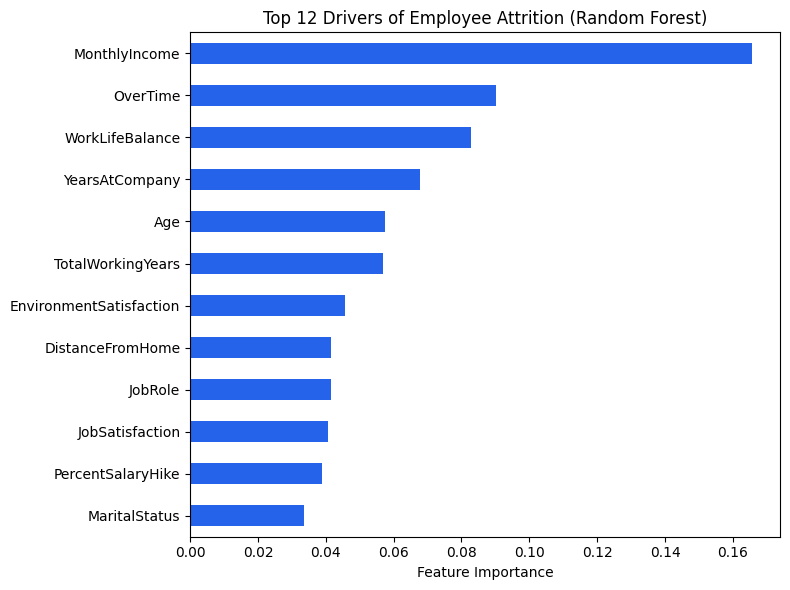

In [44]:
# feature importance
%matplotlib inline
import matplotlib.pyplot as plt   # no .use('Agg') anywhere

plt.figure(figsize=(8, 6))
importances.head(12).sort_values().plot(kind='barh', color='#2563eb')
plt.title('Top 12 Drivers of Employee Attrition (Random Forest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
# score the entire dataset with the random forest model to get attrition risk scores for all employees
X_full = X.copy()
full_proba = rf.predict_proba(X_full)[:, 1]

scored = df.copy()
scored['AttritionRiskScore'] = (full_proba * 100).round(1)
scored['RiskCategory'] = pd.cut(scored['AttritionRiskScore'],
                                 bins=[-1, 30, 60, 100],
                                 labels=['Low', 'Medium', 'High'])
scored['PredictedAttrition'] = np.where(full_proba >= 0.5, 'Yes', 'No')

scored[['EmployeeID', 'AttritionRiskScore', 'RiskCategory', 'PredictedAttrition']].head(10)



,EmployeeID,AttritionRiskScore,RiskCategory,PredictedAttrition
0,1,29.9,Low,No
1,2,41.8,Medium,No
2,3,73.3,High,Yes
3,4,41.3,Medium,No
4,5,37.8,Medium,No
5,6,31.4,Medium,No
6,7,27.2,Low,No
7,8,8.3,Low,No
8,9,21.7,Low,No
9,10,15.4,Low,No


In [50]:

scored[['EmployeeID', 'AttritionRiskScore', 'RiskCategory']] \
    .sort_values('AttritionRiskScore', ascending=False) \
    .head(10)

,EmployeeID,AttritionRiskScore,RiskCategory
374,375,79.9,High
1430,1431,75.8,High
49,50,74.7,High
349,350,74.2,High
914,915,74.2,High
1439,1440,73.8,High
1251,1252,73.7,High
485,486,73.7,High
909,910,73.6,High
2,3,73.3,High


In [51]:
# Estimated annual cost of attrition (assumption: 50% of annual salary to replace)
scored['EstReplacementCost'] = np.where(
    scored['Attrition'] == 'Yes', scored['MonthlyIncome'] * 12 * 0.5, 0)

scored.to_csv('hr_attrition_scored.csv', index=False)

print("\nTotal estimated cost of actual attrition: $",
      f"{scored['EstReplacementCost'].sum():,.0f}")
print("Employees flagged High risk:", (scored['RiskCategory'] == 'High').sum())
print("\nTop 10 attrition drivers:\n", importances.head(10))



Total estimated cost of actual attrition: $ 8,094,390
Employees flagged High risk: 93

Top 10 attrition drivers:
 MonthlyIncome              0.165615
OverTime                   0.090285
WorkLifeBalance            0.082884
YearsAtCompany             0.067661
Age                        0.057479
TotalWorkingYears          0.056807
EnvironmentSatisfaction    0.045530
DistanceFromHome           0.041579
JobRole                    0.041579
JobSatisfaction            0.040616
dtype: float64
